In [1]:
from scipy.io import mmread
import networkx as nx
import pandas as pd
import numpy as np

# node2vec
from node2vec import Node2Vec

# clustering
from sklearn.cluster import KMeans, DBSCAN

# deep stuff
import torch
from torch_geometric.utils import from_networkx

/home/jann/GAT/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from src.community_results import community_metrics, plot_communities
from graph_based_clustering import label_propagation, louvain, leiden
from src.DGIModel import DGIModel
from src.tune import tune

In [3]:
data_path = './data'

enron_path = f'{data_path}/email_enron_only.mtx'
univ_path = f'{data_path}/email_univ.edges'

In [4]:
# assume undirected graph
def read_adj_file(file, skip_rows: int = 0):
    lines = []
    with open(file, 'r') as f:
        lines = f.readlines()

    E = np.asarray([l.split() for l in lines[skip_rows:]]).astype(int)
    # index from 0
    E = E - E.min()

    adj = np.zeros((E.max() + 1, E.max() + 1))

    for (u, v) in E:
        adj[u, v] = 1
        adj[v, u] = 1

    return adj

# Load datasets

In [5]:
graphs = dict()

In [6]:
# not in standard mtx format
graphs['univ'] = nx.Graph(read_adj_file(univ_path))
graphs['univ'].number_of_nodes(), graphs['univ'].number_of_edges(), graphs['univ'].is_directed()

(1133, 5451, False)

In [7]:
graphs['enron'] = nx.Graph(mmread(enron_path).toarray())
graphs['enron'].number_of_nodes(), graphs['enron'].number_of_edges(), graphs['enron'].is_directed()

(143, 623, False)

In [8]:
graphs['karate'] = nx.karate_club_graph()
graphs['karate'] .number_of_nodes(), graphs['karate'] .number_of_edges(), graphs['karate'] .is_directed()

(34, 78, False)

# Select Dataset

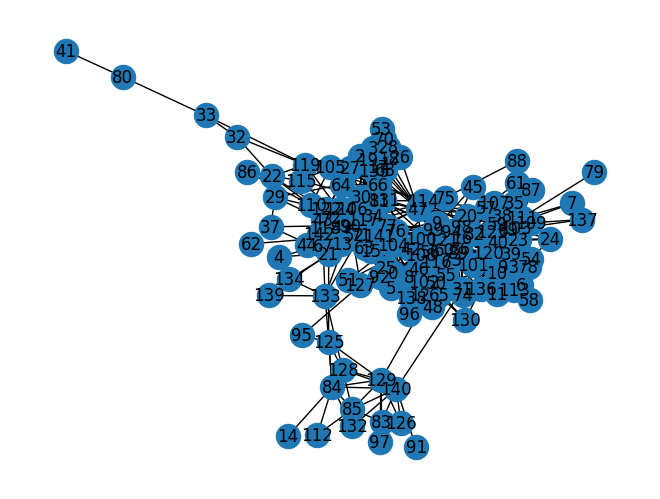

In [9]:
sel_graph = 'enron'
g = graphs[sel_graph]
nx.draw(g, with_labels=True)

# Apply graph based clustering

## Label Propagation

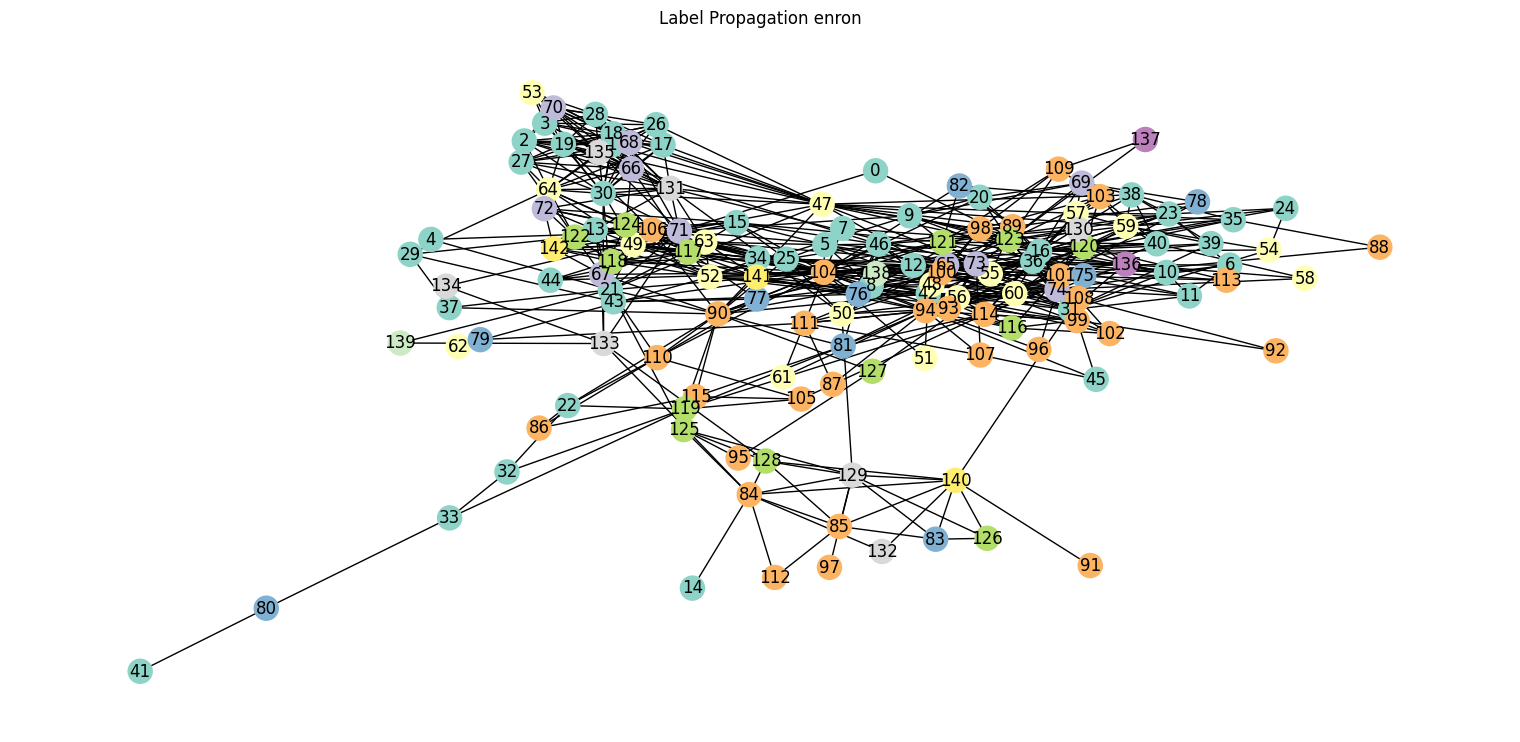

{'Number of Communities': 10,
 'Average Community Size': 14.3,
 'Modularity': 0.5052353727755462,
 'Coverage': 0.7303370786516854,
 'Performance': 0.8396533044420368}

In [10]:
lp_labels = label_propagation(g)

plot_communities(g, lp_labels, title=f"Label Propagation {sel_graph}")

# Calculate metrics for Louvain
lp_metrics = community_metrics(g, lp_labels)
lp_metrics

## Louvain

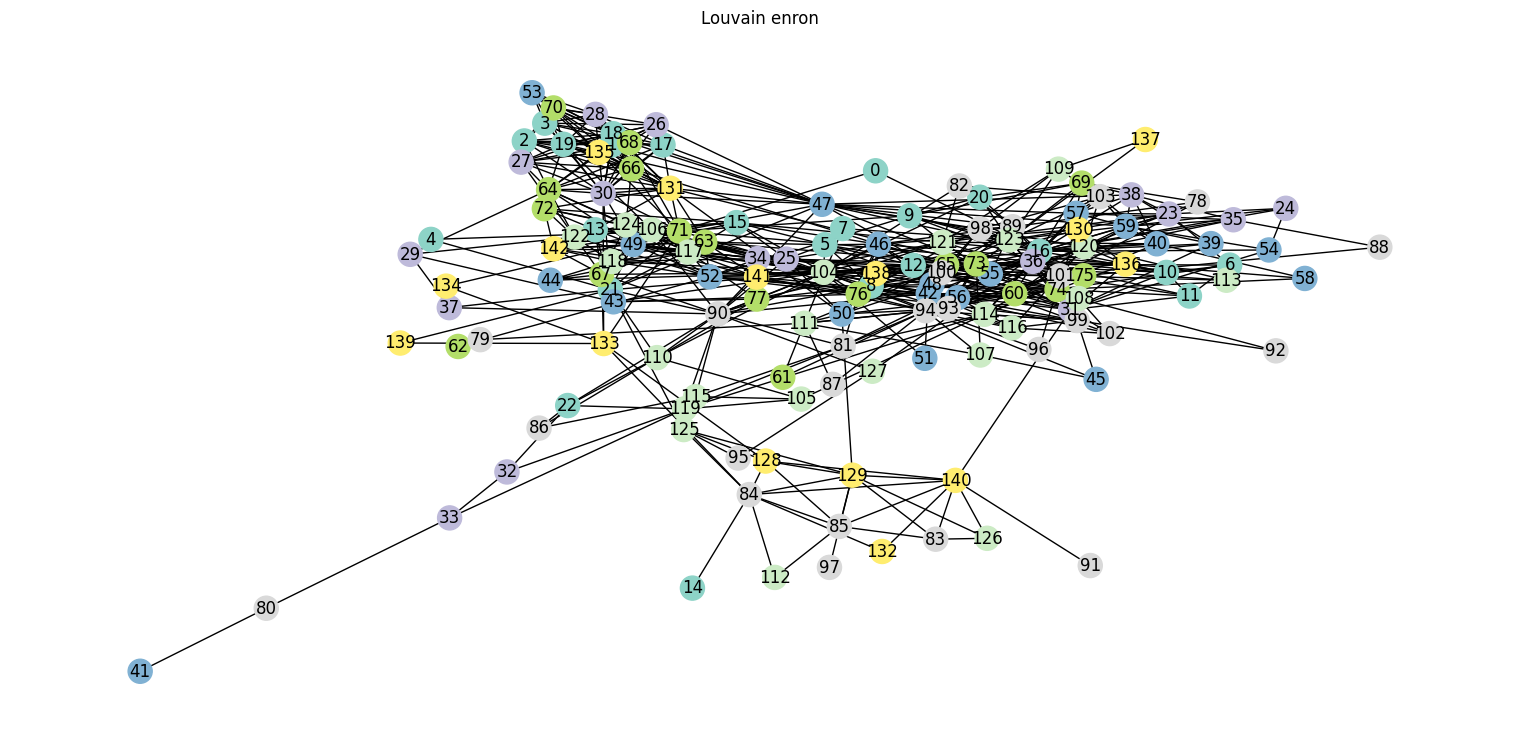

{'Number of Communities': 7,
 'Average Community Size': 20.428571428571427,
 'Modularity': 0.5678678995900847,
 'Coverage': 0.7335473515248796,
 'Performance': 0.886634492268295}

In [11]:
lv_labels = louvain(g)

plot_communities(g, lv_labels, title=f"Louvain {sel_graph}")

# Calculate metrics for Louvain
lv_metrics = community_metrics(g, lv_labels)
lv_metrics

## Leiden

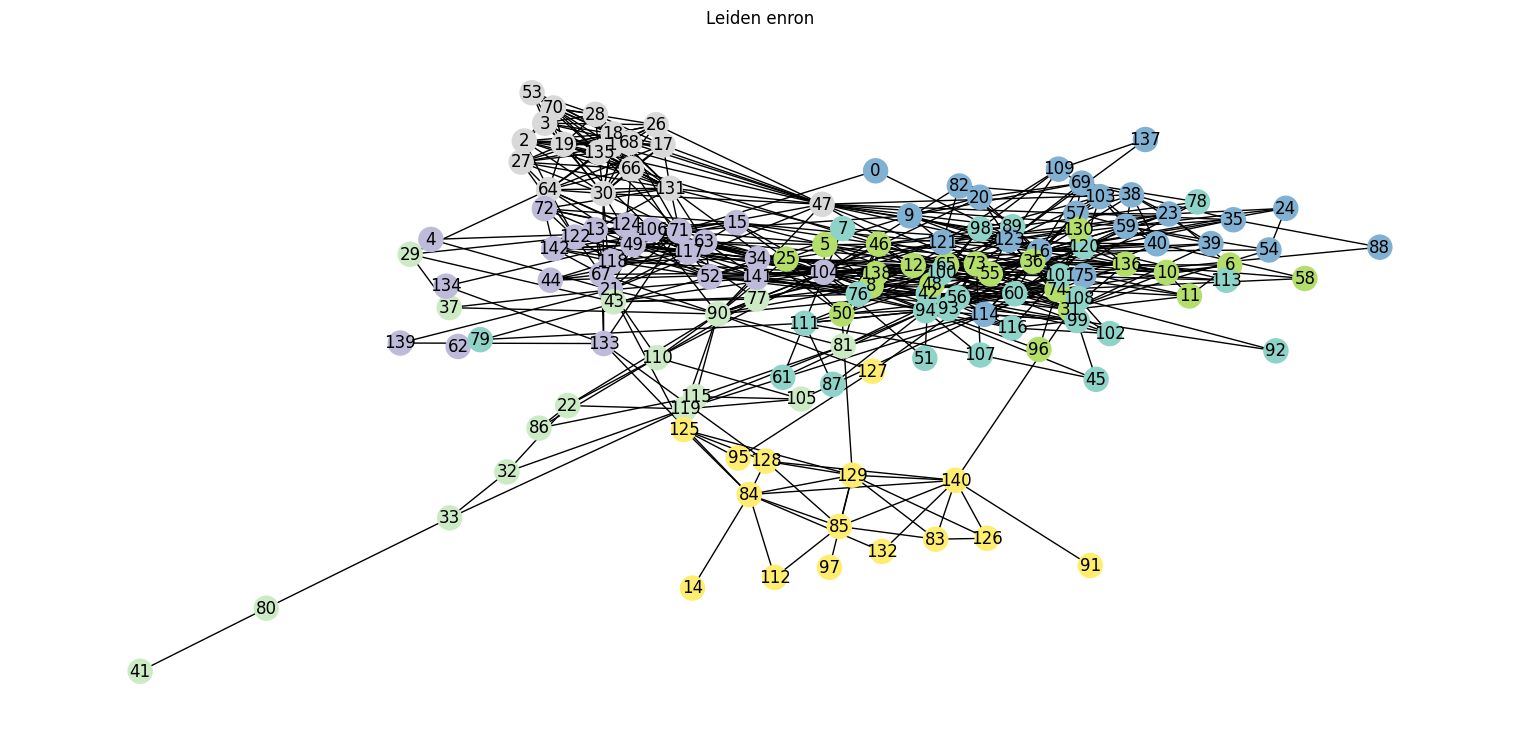

{'Number of Communities': 7,
 'Average Community Size': 20.428571428571427,
 'Modularity': 0.5678678995900848,
 'Coverage': 0.7335473515248796,
 'Performance': 0.886634492268295}

In [12]:
ld_labels = leiden(g)

plot_communities(g, ld_labels, title=f"Leiden {sel_graph}")

# Calculate metrics for Louvain
ld_metrics = community_metrics(g, ld_labels)
ld_metrics

# node2vec

In [13]:
node2vec = Node2Vec(g, dimensions=32, walk_length=20, num_walks=100, workers=4) 

# Embed nodes
node2vec_model = node2vec.fit(window=10, min_count=1, batch_words=4)  # Any keywords acceptable by gensim.Word2Vec can be passed, `dimensions` and `workers` are automatically passed (from the Node2Vec constructor)


Generating walks (CPU: 3): 100%|██████████| 25/25 [00:00<00:00, 212.28it/s]


## Clustering using node2vec only

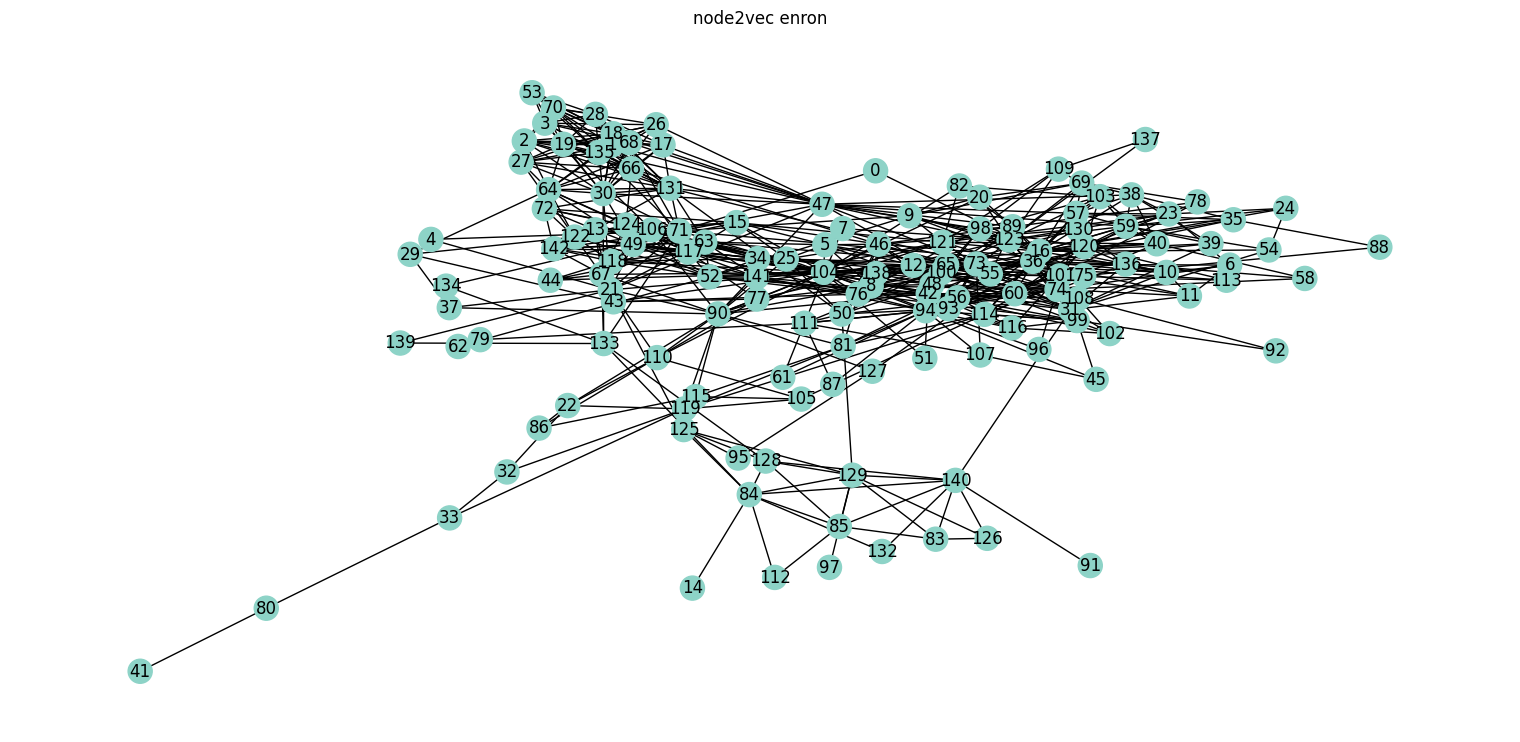

{'Number of Communities': 1,
 'Average Community Size': 143.0,
 'Modularity': 0.0,
 'Coverage': 1.0,
 'Performance': 0.061361174037230376}

In [14]:
best_eps = 0
best_mod = -1

for i in np.arange(0.1, 1.0, 0.01):
    dbscan = DBSCAN(eps=i, min_samples=5)
    communities = dbscan.fit_predict(node2vec_model.wv.get_normed_vectors())
    mod = community_metrics(g, dict(zip(range(g.number_of_nodes()), communities)))['Modularity']
    if mod > best_mod:
        best_eps, best_mod = i, mod


dbscan = DBSCAN(eps=best_eps, min_samples=5)
communities = dbscan.fit_predict(node2vec_model.wv.get_normed_vectors())
plot_communities(g, communities, title=f"node2vec {sel_graph}")
community_metrics(g, dict(zip(range(g.number_of_nodes()), communities)))

# Apply GAT Embedding

In [21]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [15]:
# Convert networkx graph to PyTorch Geometric data object
data = from_networkx(g)

# Since the graph doesn't have node features, we use an identity matrix
data.x = torch.eye(g.number_of_nodes(), dtype=torch.float)

In [17]:
best_parameters = tune(data)

[I 2024-08-11 13:07:13,492] A new study created in memory with name: no-name-210c9371-582a-4623-b948-e08128123889
[I 2024-08-11 13:07:14,873] Trial 0 finished with value: 25.142711639404297 and parameters: {'hidden_channels': 99, 'out_channels': 51, 'num_layers': 5, 'heads': 9, 'learning_rate': 0.004755802777567406, 'dropout': 0.32495611408284275, 'weight_decay': 1.4645890035904565e-05}. Best is trial 0 with value: 25.142711639404297.
[I 2024-08-11 13:07:15,984] Trial 1 finished with value: 30.612586975097656 and parameters: {'hidden_channels': 76, 'out_channels': 40, 'num_layers': 5, 'heads': 12, 'learning_rate': 0.008552967843431328, 'dropout': 0.16097527310661702, 'weight_decay': 9.540538346312346e-05}. Best is trial 0 with value: 25.142711639404297.
[I 2024-08-11 13:07:16,504] Trial 2 finished with value: 0.5455633401870728 and parameters: {'hidden_channels': 120, 'out_channels': 51, 'num_layers': 2, 'heads': 9, 'learning_rate': 0.0008141596772828898, 'dropout': 0.3768863700721476,

{'hidden_channels': 67,
 'out_channels': 17,
 'num_layers': 5,
 'heads': 7,
 'learning_rate': 0.0015064383783733053,
 'dropout': 0.12177827937694731,
 'weight_decay': 3.059808407810427e-05}

In [19]:
hidden_channels = 67
out_channels = 17
num_layers = 5
heads = 7
dropout = 0.1
lr = 1e-3
l2_reg = 3e-5
epochs = 400

In [22]:
model = DGIModel(in_channels=data.num_features, hidden_channels=hidden_channels, out_channels=out_channels, num_layers=num_layers, heads=heads, dropout=dropout)
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=l2_reg)

def train():
    model.train()
    optimizer.zero_grad()
    pos_z, neg_z, summary = model(data)
    loss = model.dgi.loss(pos_z, neg_z, summary)
    loss.backward()
    optimizer.step()
    return loss.item()

# Training the model
for epoch in range(800):
    loss = train()
    if epoch % 10 == 0:
        print(f'Epoch {epoch}, Loss: {loss}')


Epoch 0, Loss: 1.3926091194152832
Epoch 10, Loss: 0.41256850957870483
Epoch 20, Loss: 0.44425007700920105
Epoch 30, Loss: 0.03869400918483734
Epoch 40, Loss: 1.046901822090149
Epoch 50, Loss: 0.011201975867152214
Epoch 60, Loss: 0.05074189975857735
Epoch 70, Loss: 0.03199056163430214
Epoch 80, Loss: 0.019283955916762352
Epoch 90, Loss: 0.01919638365507126
Epoch 100, Loss: 0.009574148803949356
Epoch 110, Loss: 0.08853870630264282
Epoch 120, Loss: 0.12569855153560638
Epoch 130, Loss: 0.023209651932120323
Epoch 140, Loss: 0.0038581753615289927
Epoch 150, Loss: 0.006507116369903088
Epoch 160, Loss: 0.00020260388555470854
Epoch 170, Loss: 0.0006286465795710683
Epoch 180, Loss: 0.00149214593693614
Epoch 190, Loss: 0.006486105266958475
Epoch 200, Loss: 0.24797877669334412
Epoch 210, Loss: 0.003929527942091227
Epoch 220, Loss: 0.05868857726454735
Epoch 230, Loss: 0.01881656050682068
Epoch 240, Loss: 0.015126453712582588
Epoch 250, Loss: 0.03446747735142708
Epoch 260, Loss: 0.002039685379713773

In [23]:
# Extract node embeddings
model.eval()
with torch.no_grad():
    node_embeddings = model.encoder(data.x, data.edge_index)

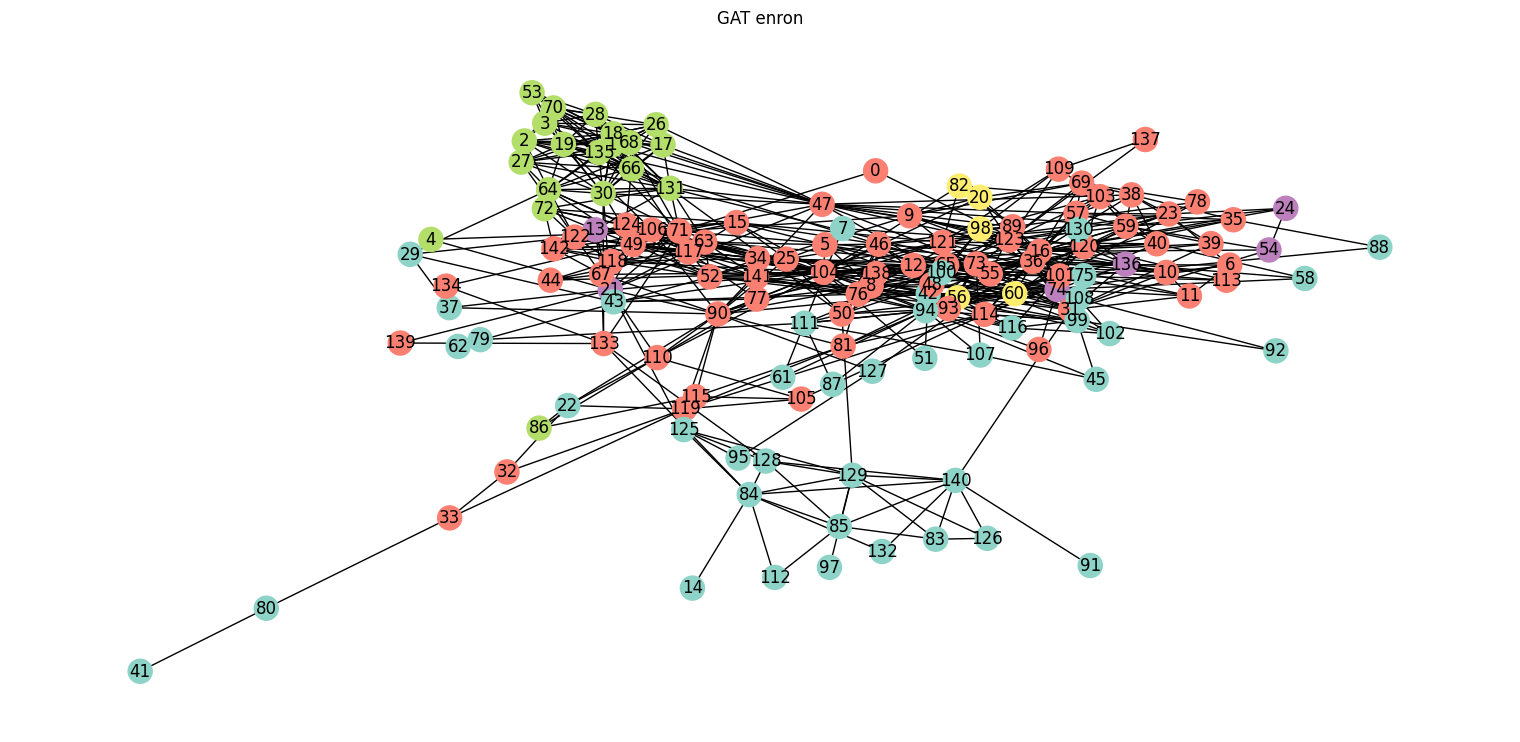

{'Number of Communities': 5,
 'Average Community Size': 28.6,
 'Modularity': 0.31790590241904104,
 'Coverage': 0.7062600321027287,
 'Performance': 0.6814734561213435}

In [24]:
best_eps = 0
best_mod = -1

for i in np.arange(0.1, 1.0, 0.01):
    dbscan = DBSCAN(eps=i, min_samples=5)
    communities = dbscan.fit_predict(node_embeddings.detach().cpu().numpy())
    mod = community_metrics(g, dict(zip(range(g.number_of_nodes()), communities)))['Modularity']
    if mod > best_mod:
        best_eps, best_mod = i, mod


dbscan = DBSCAN(eps=best_eps, min_samples=5)
communities = dbscan.fit_predict(node_embeddings.detach().cpu().numpy())
plot_communities(g, communities, title=f"GAT {sel_graph}")
community_metrics(g, dict(zip(range(g.number_of_nodes()), communities)))

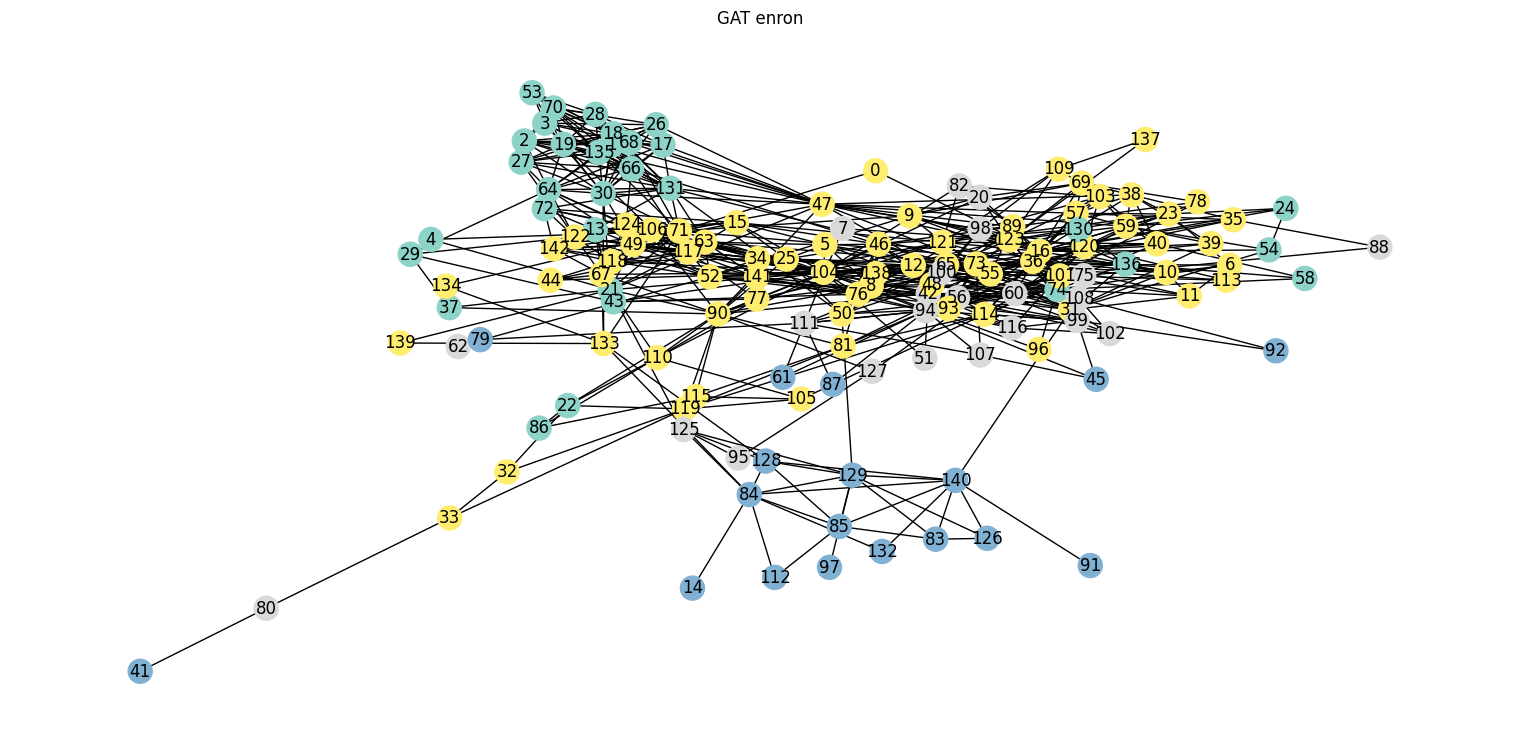

{'Number of Communities': 4,
 'Average Community Size': 35.75,
 'Modularity': 0.3101662076268457,
 'Coverage': 0.7142857142857143,
 'Performance': 0.6995961784694179}

In [25]:
best_n = 0
best_mod = -1

for i in range(2, 11):
    kmeans = KMeans(n_clusters=i)
    communities = kmeans.fit_predict(node_embeddings.detach().cpu().numpy())
    mod = community_metrics(g, dict(zip(range(g.number_of_nodes()), communities)))['Modularity']
    if mod > best_mod:
        best_n, best_mod = i, mod

kmeans = KMeans(n_clusters=best_n)  # The Karate Club graph has two main communities
communities = kmeans.fit_predict(node_embeddings.detach().cpu().numpy())

plot_communities(g, communities, title=f"GAT {sel_graph}")
community_metrics(g, dict(zip(range(g.number_of_nodes()), communities)))

In [ ]:
# Plotting the communities
# plt.figure(figsize=(8, 6))
# nx.draw(G, node_color=communities, with_labels=True, cmap=plt.cm.rainbow, node_size=500)
# plt.title("Detected Communities in Karate Club Graph")
# plt.show()